In [4]:
## Cell 1 — Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)


## Cell 2 — Load Feature Engineered Dataset
df = pd.read_csv("all_seasons_feature_engineered.csv")

print(df.shape)
df.head()

(12844, 143)


,age,player_height,player_weight,college,draft_year,draft_round,draft_number,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season,height_m,BMI,season_start,experience,is_drafted,team_abbreviation_BKN,team_abbreviation_BOS,team_abbreviation_CHA,team_abbreviation_CHH,team_abbreviation_CHI,team_abbreviation_CLE,team_abbreviation_DAL,team_abbreviation_DEN,team_abbreviation_DET,team_abbreviation_GSW,team_abbreviation_HOU,team_abbreviation_IND,team_abbreviation_LAC,team_abbreviation_LAL,team_abbreviation_MEM,team_abbreviation_MIA,team_abbreviation_MIL,team_abbreviation_MIN,team_abbreviation_NJN,team_abbreviation_NOH,team_abbreviation_NOK,team_abbreviation_NOP,team_abbreviation_NYK,team_abbreviation_OKC,team_abbreviation_ORL,team_abbreviation_PHI,team_abbreviation_PHX,team_abbreviation_POR,team_abbreviation_SAC,team_abbreviation_SAS,team_abbreviation_SEA,team_abbreviation_TOR,team_abbreviation_UTA,team_abbreviation_VAN,team_abbreviation_WAS,country_Argentina,country_Australia,country_Austria,country_Bahamas,country_Belize,country_Bosnia,country_Bosnia & Herzegovina,country_Bosnia and Herzegovina,country_Brazil,country_Cabo Verde,country_Cameroon,country_Canada,country_China,country_Colombia,country_Congo,country_Croatia,country_Czech Republic,country_DRC,country_Democratic Republic of the Congo,country_Denmark,country_Dominican Republic,country_Egypt,country_England,country_Finland,country_France,country_Gabon,country_Georgia,country_Germany,country_Ghana,country_Great Britain,country_Greece,country_Guinea,country_Haiti,country_Iran,country_Ireland,country_Israel,country_Italy,country_Jamaica,country_Japan,country_Latvia,country_Lithuania,country_Macedonia,country_Mali,country_Mexico,country_Montenegro,country_Netherlands,country_New Zealand,country_Nigeria,country_Panama,country_Poland,country_Portugal,country_Puerto Rico,country_Republic of the Congo,country_Russia,country_Saint Lucia,country_Scotland,country_Senegal,country_Serbia,country_Serbia and Montenegro,country_Slovenia,country_South Korea,country_South Sudan,country_Spain,country_St. Vincent & Grenadines,country_Sudan,country_Sudan (UK),country_Sweden,country_Switzerland,country_Tanzania,country_Trinidad and Tobago,country_Tunisia,country_Turkey,country_U.S. Virgin Islands,country_US Virgin Islands,country_USA,country_USSR,country_Ukraine,country_United Kingdom,country_Uruguay,country_Venezuela,country_Yugoslavia,height_category_Wing,height_category_Big,weight_category_Medium,weight_category_Heavy
0,22.0,193.04,94.800728,Louisiana State,1996.0,2.0,42.0,64,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97,1.9304,25.439997,1996,0.0,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False
1,28.0,190.50,86.182480,Northwestern Oklahoma,1994.0,2.0,34.0,4,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97,1.9050,23.748109,1996,2.0,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [9]:
## Cell 3 — Define Target Variable

## Choose what you want to predict.

## Example (recommended):

## Predict Points Per Game (PTS)

target = "pts"

X = df.drop(columns=[target])
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (12844, 142)
Target: (12844,)


In [10]:
## Cell 4 — Encode Categorical Variables

## Convert categorical features into numerical values.

X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(12844, 522)


In [11]:
## Cell 5 — Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(10275, 522)
(2569, 522)


In [12]:
## Cell 6 — Train Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [13]:
print(X_train.isna().sum())

age                  0
player_height        0
player_weight        0
draft_year        1872
draft_round       1910
                  ... 
season_2018-19       0
season_2019-20       0
season_2020-21       0
season_2021-22       0
season_2022-23       0
Length: 522, dtype: int64


In [14]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])

draft_year      1872
draft_round     1910
draft_number    1912
experience      1872
dtype: int64


In [15]:
X_train[['draft_year', 'draft_round', 'draft_number', 'experience']] = (
    X_train[['draft_year', 'draft_round', 'draft_number', 'experience']].fillna(-1)
)

X_test[['draft_year', 'draft_round', 'draft_number', 'experience']] = (
    X_test[['draft_year', 'draft_round', 'draft_number', 'experience']].fillna(-1)
)

In [16]:
## Cell 6 — Train Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [17]:
## Cell 7 — Evaluate Linear Regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression")
print("-------------------")
print("MAE :", round(lr_mae, 3))
print("RMSE:", round(lr_rmse, 3))
print("R²  :", round(lr_r2, 3))

Linear Regression
-------------------
MAE : 1.389
RMSE: 1.976
R²  : 0.893


In [18]:
## Cell 8 — Train Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [19]:
## Cell 9 — Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("----------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Random Forest
----------------
MAE : 0.757
RMSE: 1.084
R²  : 0.968


In [20]:
## Cell 10 — Compare Models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison.sort_values("R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
1,Random Forest,0.757155,1.083655,0.967946
0,Linear Regression,1.388737,1.975904,0.893432


In [21]:
## Cell 11 — Feature Importance (Random Forest)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
8,ast,0.381634
12,usg_pct,0.336234
7,reb,0.168745
13,ts_pct,0.038336
6,gp,0.016446
11,dreb_pct,0.016377
14,ast_pct,0.012842
10,oreb_pct,0.006781
9,net_rating,0.002464
17,season_start,0.002239


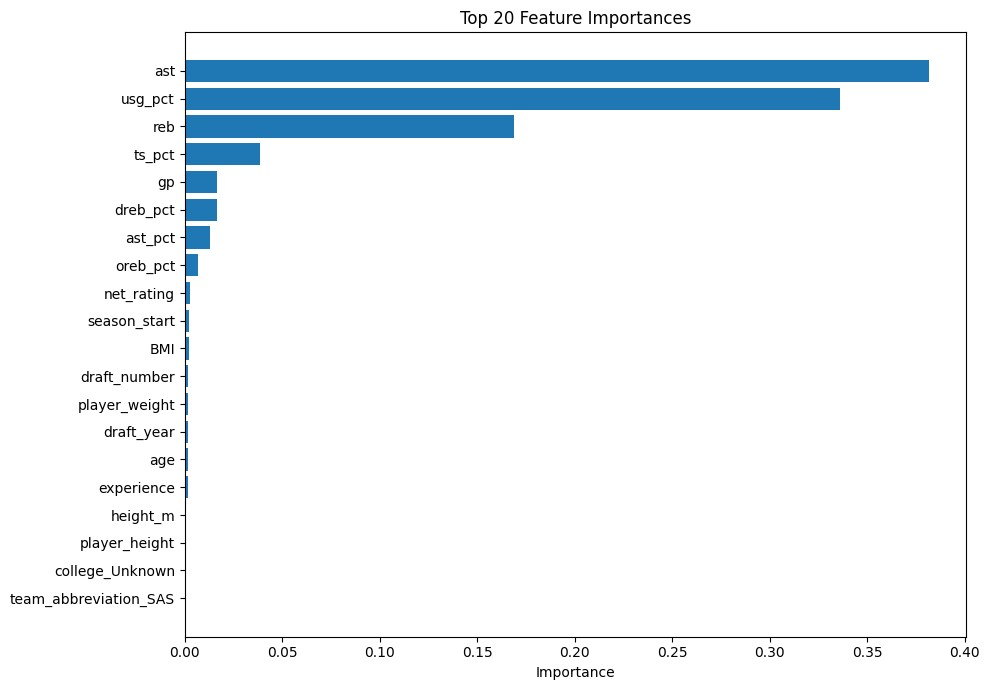

In [22]:
## Cell 12 — Plot Top 20 Important Features
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(top20["Feature"], top20["Importance"])

plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

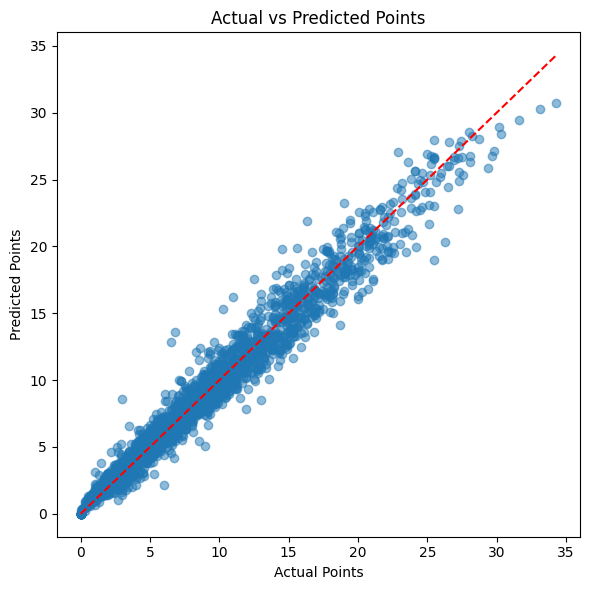

In [23]:
## Cell 13 — Actual vs Predicted (Random Forest)
plt.figure(figsize=(6, 6))

plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Actual vs Predicted Points")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.tight_layout()
plt.show()

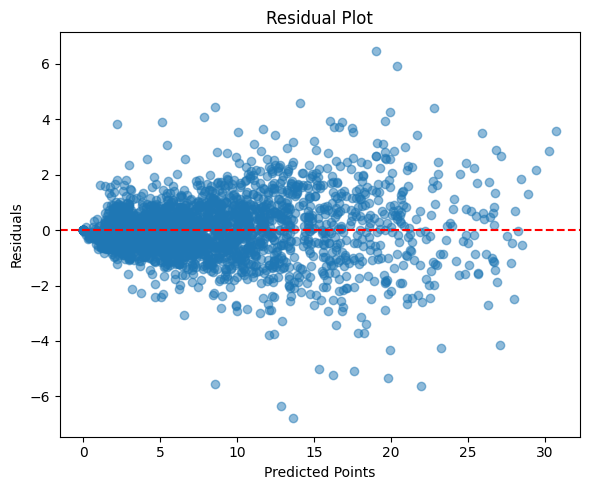

In [24]:
## Cell 14 — Residual Plot
residuals = y_test - rf_predictions

plt.figure(figsize=(6, 5))

plt.scatter(rf_predictions, residuals, alpha=0.5)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Points")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

In [25]:
## Cell 15 — Modeling Summary
print("Modeling Summary")
print("=" * 40)

print(comparison)

print("\nBest Model:")
print(comparison.sort_values("R² Score", ascending=False).iloc[0])

Modeling Summary
               Model       MAE      RMSE  R² Score
0  Linear Regression  1.388737  1.975904  0.893432
1      Random Forest  0.757155  1.083655  0.967946

Best Model:
Model       Random Forest
MAE              0.757155
RMSE             1.083655
R² Score         0.967946
Name: 1, dtype: object


In [26]:
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model saved successfully!")

Model saved successfully!
